In [1]:
%cd /leonardo_work/IscrC_LR4LSDS/GT/encoderops/

/leonardo_work/IscrC_LR4LSDS/GT/encoderops


In [2]:
from wandb.apis.public import Api
from pathlib import Path
from datetime import datetime

from src.model import EvolutionOperator
from src.data import SSTDataModule
from src.configs import TrainerArgs, SSTDataArgs # noqa

import torch
import scipy.linalg
import numpy as np
import pandas as pd

In [3]:
def check_date(date_str, cutoff_date = datetime(2025, 11, 10)):
   return datetime.strptime(date_str.rstrip('Z'), '%Y-%m-%dT%H:%M:%S.%f') > cutoff_date

def get_residuals(l, Q, cov_X, cov_Y, cov_XY):
    # Compute the residuals as defined in Eq. 3.2 of M. Colbrook's ResDMD
    # https://doi.org/10.1017/jfm.2022.1052

    res2 = []
    for i, eig in enumerate(l):
        q = Q[:, i]
        num = np.vdot(q, (cov_Y - eig * cov_XY.T - eig.conj() * cov_XY + np.abs(eig)**2 * cov_X) @ q)
        den = np.vdot(q, cov_X @ q)
        res2.append(num / den)

    return np.sqrt(np.array(res2))

@torch.no_grad()
def compute_eig_residuals(model: EvolutionOperator, reg:float=1e-4):
    if model.forecast:
        d = model.trainer_args.latent_dim + model.encoder_args["input_shape"]
    else:
        d = model.trainer_args.latent_dim
    cov_X = model.covariances.cov_X.numpy(force=True)
    cov_Y = model.covariances.cov_Y.numpy(force=True)
    regularizer = reg * np.eye(d)
    cross_cov = model.covariances.cov_XY.numpy(force=True)
    l, Q = scipy.linalg.eig(cross_cov, cov_X + regularizer)
    residuals = get_residuals(l, Q, cov_X, cov_Y, cross_cov)
    return residuals, l

In [4]:
import pickle
with open("/leonardo_work/IscrC_LR4LSDS/encoderops/exps/ENSO/climate_latent_dim_ablation_report.pkl", "rb") as f:
    report = pickle.load(f)

In [ ]:
def load_runs_history(project_id: str = "encoderops-ENSO", model_size: str = "small"):
    print(f"Loading {project_id} runs - model size: {model_size}")
    runs = Path(f"/leonardo_work/IscrC_LR4LSDS/GT/encoderops/logs/{project_id}").glob("**/checkpoints/last.ckpt")
    runs = list(runs)
    residuals = {}
    for run in runs:
        model = EvolutionOperator.load_from_checkpoint(run)
        if model.encoder_args.get('size', '__no_size__') == model_size:
            residuals[model.trainer_args.latent_dim] = compute_eig_residuals(model)
    residuals = sorted(residuals.items())
    # Sorting residuals
    latent_dims, residuals_and_eigs = list(zip(*residuals))
    res, eigs = list(zip(*residuals_and_eigs))
    sorting_permutations = [np.argsort(np.abs(eig)) for eig in eigs]
    res = [r[perm] for r, perm in zip(res, sorting_permutations)]
    eigs = [e[perm] for e, perm in zip(eigs, sorting_permutations)]
    dfs = [pd.DataFrame({'residuals': r, 'eigenvalues': e}) for r, e in zip(res, eigs)]
    return latent_dims, dfs

In [12]:
residuals = {}
for model_size in ['small', 'medium', 'large']:
    project_id = "encoderops-ENSO"
    residuals['CNN_'+model_size] = load_runs_history(project_id, model_size)

Loading encoderops-ENSO runs - model size: small
TrainerArgs(latent_dim=64, encoder_lr=0.001, linear_lr=0.001, epochs=100, batch_size=64, max_grad_norm=0.2, normalize_lin=True, regularization=0, loss='l2', min_encoder_lr=1e-05, normalize_latents='simnorm', simnorm_dim=2, seed=42, forecast=False, share_encoder=True)
TrainerArgs(latent_dim=16, encoder_lr=0.001, linear_lr=0.001, epochs=100, batch_size=64, max_grad_norm=0.2, normalize_lin=True, regularization=0, loss='l2', min_encoder_lr=1e-05, normalize_latents='simnorm', simnorm_dim=2, seed=0, forecast=False, share_encoder=True)
TrainerArgs(latent_dim=32, encoder_lr=0.001, linear_lr=0.001, epochs=100, batch_size=64, max_grad_norm=0.2, normalize_lin=True, regularization=0, loss='l2', min_encoder_lr=1e-05, normalize_latents='simnorm', simnorm_dim=2, seed=42, forecast=False, share_encoder=True)
TrainerArgs(latent_dim=512, encoder_lr=0.001, linear_lr=0.001, epochs=100, batch_size=64, max_grad_norm=0.2, normalize_lin=True, regularization=0, l

KeyboardInterrupt: 

In [8]:
import pickle
pickle.dump(residuals, open("/leonardo_work/IscrC_LR4LSDS/encoderops/exps/ENSO/climate_eig_residuals_latent_dim_ablation.pkl", "wb"))

In [40]:
import matplotlib.pyplot as plt
import matplotx
import json
def plot_color_palette(color_dict: dict):
    """
    Plots the color dictionary (e.g., {"gray": ["#fcfc..", ...]}) using Matplotlib.
    
    Args:
        color_dict: Dictionary where keys are color names (str) and values are 
                    lists of hex color codes (list[str]).
    """
    if not color_dict:
        print("The color dictionary is empty.")
        return

    # Prepare data
    color_names = list(color_dict.keys())
    num_colors = len(color_names)
    shades_per_color = len(next(iter(color_dict.values())))

    # Create figure and axes
    fig_height = num_colors * 0.5  # Adjust height based on number of color families
    fig, ax = plt.subplots(figsize=(10, fig_height))
    fig.subplots_adjust(hspace=0, wspace=0)

    # Plot each color family
    for i, name in enumerate(color_names):
        colors = color_dict[name]
        
        # Create a horizontal strip for the color family
        for j, hex_code in enumerate(colors):
            ax.barh(
                y=i,              # Vertical position (color family index)
                width=1.,          # Width of a single shade block
                left=j,           # Starting position for this shade
                color=hex_code,
                height=1.0,       # Height of the strip
                edgecolor='none'
            )
            ax.text(x =j + 0.5, y=i, s=j, va='center', ha='center', fontsize=8, color='white' if j > shades_per_color / 2 else 'black')

    # Configure axes
    ax.set_yticks(range(num_colors))
    ax.set_yticklabels(color_names)
    ax.set_xticks([])
    ax.set_xlabel('Shade Index (1 to 12)')
    
    # Clean up and display
    ax.set_ylim(-0.5, num_colors - 0.5) # Set limits to center the bars
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    plt.tight_layout()
    plt.show()

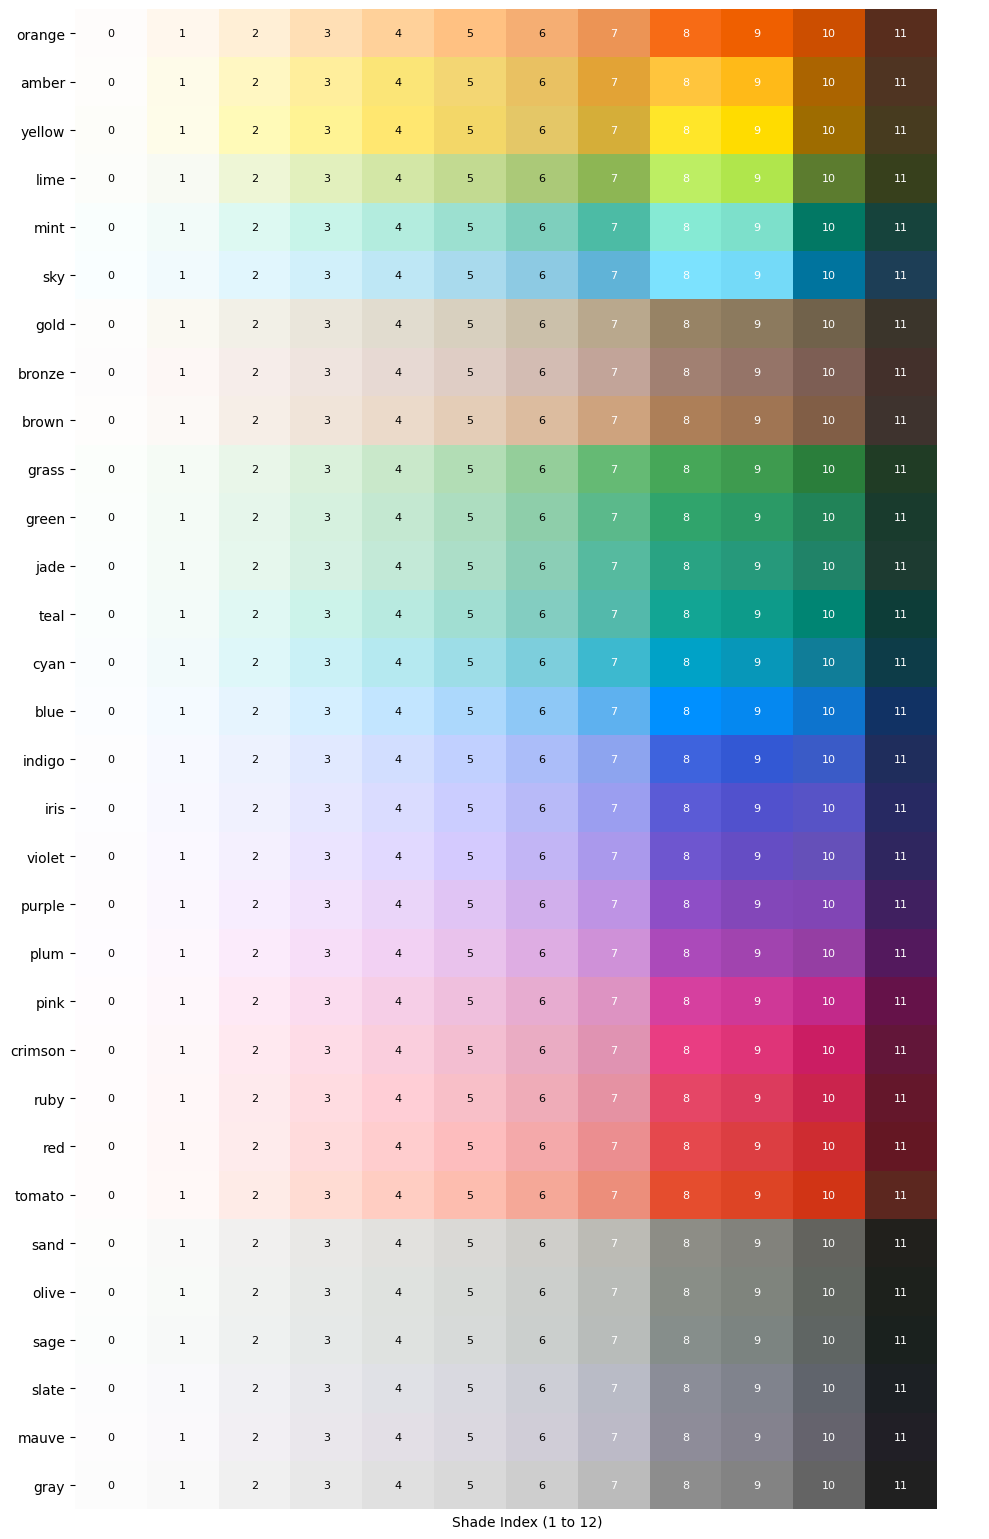

In [54]:
with open("/leonardo_work/IscrC_LR4LSDS/encoderops/exps/trpcage/colors.json") as f:
    color_palette = json.load(f)
plot_color_palette(color_palette)

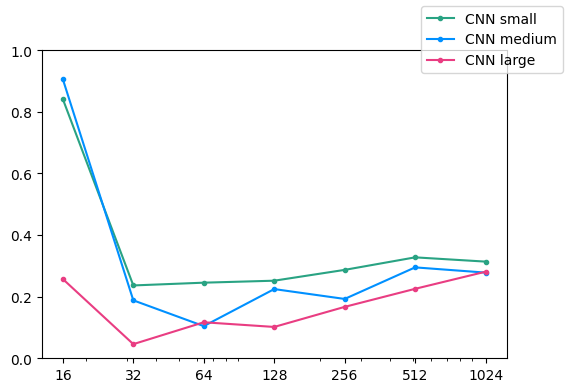

In [105]:
fig, ax = plt.subplots(figsize=(6,4))
for size, color in zip(['small', 'medium', 'large'], ['jade', 'blue', 'crimson']):
    res = residuals['CNN_'+size]
    for i in [3]:
        x = []
        y = []
        for idx, latent_dims in enumerate(res[0]):
            if latent_dims >= 16:
                x.append(latent_dims)
                df = res[1][idx]
                df['residuals'] = np.real(df['residuals'])
                df = df.drop_duplicates(subset='residuals')
                sorted_residuals = df['residuals'].values
                y.append(sorted_residuals[-i])
        ax.plot(x, y, ".-", label = f"CNN {size}", color=color_palette[color][8])
ax.set_xscale('log')
ax.set_ylim(0, 1)
ax.set_xticks(x, x)
fig.legend()

PermissionError: [Errno 13] Permission denied: 'exps/ENSO/cnn_ablations.svg'

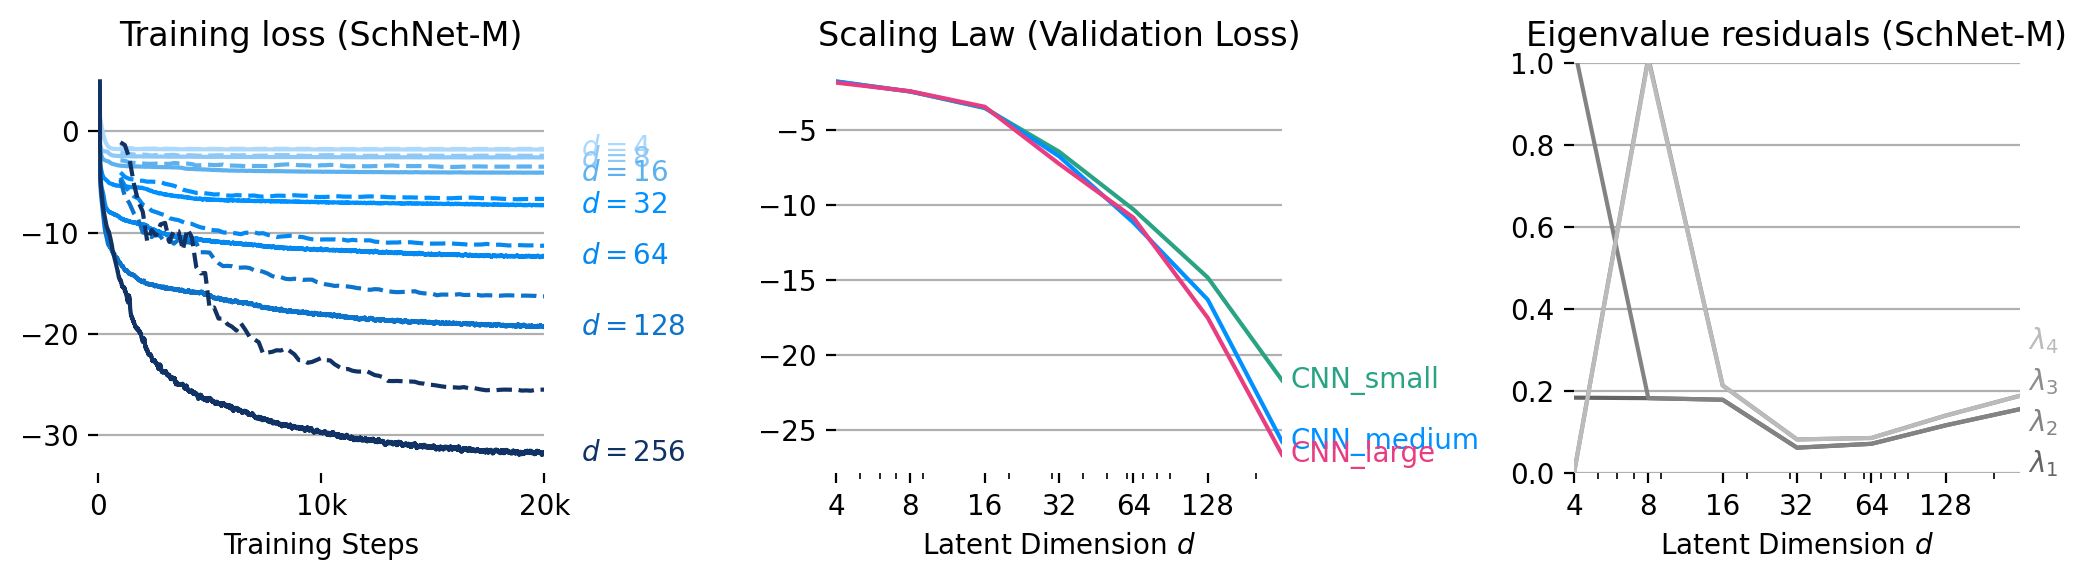

In [66]:
fig, axs = plt.subplots(ncols=3, figsize=(10.5,3), dpi=200)
# Loss
project_id = "CNN_medium"
data, top_4_residuals, latent_dims = report[project_id]
ax = axs[0]
for k, (feats, summary) in enumerate(data):
    if feats < 500:
        train_steps = summary['_step'][~summary['train_loss'].isna()]
        train_losses = summary['train_loss'][~summary['train_loss'].isna()]
        ax.plot(train_steps, -train_losses.rolling(75).mean(), color=color_palette['blue'][k + 5], label=fr"$d = {feats}$")

        val_steps = summary['_step'][~summary['val_loss_step'].isna()]
        val_losses = summary['val_loss_step'][~summary['val_loss_step'].isna()]
        ax.plot(val_steps, -val_losses.rolling(5).mean(), color=color_palette['blue'][k + 5], ls='--')
matplotx.line_labels(ax=ax, min_label_distance=1)
#ax.set_ylim(-13, 0)
ax.margins(x=0)
ax.set_xlabel('Training Steps')
ax.set_xticks([0, 10000, 20000], [0 , '10k', '20k'])
ax.grid(axis='y')
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_title(r'Training loss (SchNet-M)')
# Residuals 
ax = axs[2]
for k, y in enumerate(top_4_residuals):
    ax.plot(latent_dims[:7], y[:7], color=color_palette['gray'][-(k + 2)], label=fr"$\lambda_{k + 1}$")
matplotx.line_labels(ax=ax, min_label_distance=0.1)
ax.set_ylim(0, 1)
ax.margins(x=0)
ax.set_xscale('log')
ax.grid(axis='y')
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([2**(k + 2) for k in range(6)], [2**(k+2) for k in range(6)])
ax.set_xlabel(r'Latent Dimension $d$')
ax.set_title('Eigenvalue residuals (SchNet-M)')
# Scaling
ax = axs[1]
final_losses = {}
for k, (data, _, _) in report.items():
    _feats = []
    _losses = []
    _val_losses = []
    for feats, summary in data:
        if feats < 500:
            train_steps = summary['trainer/global_step'][~summary['train_loss'].isna()]
            train_vals = summary['train_loss'][~summary['train_loss'].isna()]

            val_steps = summary['_step'][~summary['val_loss_step'].isna()]
            val_losses = summary['val_loss_step'][~summary['val_loss_step'].isna()]
            _feats.append(feats)
            _losses.append(-train_vals.values[-1])
            _val_losses.append(-val_losses.values[-1])
    final_losses[k] = [_feats, _losses, _val_losses]
final_losses['CNN_small'].append(color_palette['jade'][8])
final_losses['CNN_medium'].append(color_palette['blue'][8])
final_losses['CNN_large'].append(color_palette['crimson'][8])
for k, (feats, losses, val_losses, color) in final_losses.items():
    ax.plot(feats, val_losses, color=color, label =k)
matplotx.line_labels(ax=ax, min_label_distance=0.1)
ax.margins(x=0)
ax.set_xscale('log')
ax.grid(axis='y')
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([2**(k + 2) for k in range(6)], [2**(k+2) for k in range(6)])
ax.set_xlabel(r'Latent Dimension $d$')
ax.set_title('Scaling Law (Validation Loss)')

fig.tight_layout()
fig.savefig("exps/ENSO/cnn_ablations.svg")
#ax.set_title(r'$-\varepsilon(\varphi, P)$')